# 05 — Comparación de familias de modelo (línea base)

Este notebook compara tres familias de modelos, cada una elegida por una
razón distinta y no redundante:

- **Lineal (OLS).** Sirve de referencia interpretable: sus coeficientes son
  directamente el efecto marginal de cada variable sobre `log(PRICE)`, algo
  que ninguna de las otras dos familias ofrece. Si su rendimiento resultase
  comparable al de los modelos no lineales, sería la opción preferida por esa
  transparencia — de ahí que se la incluya como candidata real y no como mero
  punto de comparación.
- **Random Forest.** Un ensamblado de árboles por *bagging* que puede capturar
  no linealidades e interacciones entre variables sin tener que especificarlas
  a mano (a diferencia del OLS, que solo ve lo que se le codifica
  explícitamente). Al promediar árboles entrenados sobre remuestreos
  independientes, reduce varianza a costa de perder la lectura directa de
  coeficientes.
- **XGBoost.** Un ensamblado de árboles por *boosting*: en vez de promediar
  árboles independientes, los ajusta secuencialmente, cada uno corrigiendo el
  error del conjunto anterior. Es la segunda familia no lineal, no porque se
  espere que rinda distinto de Random Forest por las mismas variables, sino
  porque parte de un mecanismo de reducción de error distinto (reducir sesgo
  de forma iterativa, frente a reducir varianza por promediado) y con
  hiperparámetros de regularización propios que 06 explorará por separado.

Compara, con hiperparámetros por defecto, las combinaciones (familia de modelo
× variante de dataset) que `04` dejó preparadas, para resolver sus
comparaciones pendientes y elegir con qué variante sigue cada familia en
`06_fine_tuning.ipynb`. No es una búsqueda de hiperparámetros — eso es 06 — es
la elección de punto de partida: aislar el efecto de la variante de dataset
antes de gastar presupuesto de búsqueda ajustando un modelo con datos que
podrían no ser los mejores para esa familia.

### Elecciones metodológicas

**Validación cruzada.** `KFold(5, shuffle=True)`  Se establecen cinco particiones aleatorias sobre el dataset *train* para cada proceso de *scoring*. Con más
folds cada modelo se entrena con más datos (menos sesgo) pero la estimación
del error se apoya en muestras de validación más pequeñas y ruidosas (más
varianza).

**Métrica.** RMSE (raíz del error cuadrático medio) sobre `log(PRICE)` —
la escala en la que se entrena, y la que fija `04`. Trabajar en log y no en
euros no es un detalle técnico: el precio de vivienda es una variable de
cola larga (unos pocos inmuebles muy caros dominarían el error en euros) y
sus errores relevantes son multiplicativos, no aditivos — equivocarse en
20.000€ importa mucho para un piso de 100.000€ y poco para uno de 900.000€.
Al modelar `log(PRICE)`, el RMSE en esa escala aproxima el error porcentual
típico de la predicción, y penaliza igual en términos relativos los errores. 
El propio RMSE, penaliza más que proporcionalmente los errores (relativos) grandes
respecto a los pequeños, frente a una alternativa como el error absoluto
medio.

In [1]:
import os, sys, warnings
from pathlib import Path
from time import perf_counter

RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from xgboost import XGBRegressor

from src import rutas
from src.modelado import (
    RegresionStepwiseBIC, cv_aleatorio, evaluar_cv, registrar_experimento,
)

pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid")

SEMILLA = 42
PROCESADOS = rutas.PROCESADOS
RUTA_RESULTADOS = rutas.RUTA_RESULTADOS_BASELINE
RUTA_RESULTADOS.parent.mkdir(parents=True, exist_ok=True)
RUTA_RESULTADOS.unlink(missing_ok=True)  # este notebook regenera su propio registro en cada ejecución


## 1. Carga

Las matrices de train que escribió `04`, más el objetivo y los grupos de CV.

In [2]:
y_train = pd.read_parquet(PROCESADOS / "y_train.parquet")["log_price"]

datasets = {
    nombre: pd.read_parquet(PROCESADOS / f"X_train_{nombre}.parquet")
    for nombre in [
        "incluido", "desplegable", "lineal_completo",
        "arboles", "arboles_podado", "arboles_completo",
        "arboles_desplegable", "arboles_podado_desplegable", "arboles_completo_desplegable",
    ]
}

for nombre, X in datasets.items():
    print(f"{nombre:30s} {X.shape[0]:>6,} x {X.shape[1]:>3} columnas")

incluido                       60,375 x  30 columnas
desplegable                    60,375 x  20 columnas
lineal_completo                60,375 x  56 columnas
arboles                        60,375 x  28 columnas
arboles_podado                 60,375 x  17 columnas
arboles_completo               60,375 x  36 columnas
arboles_desplegable            60,375 x  21 columnas
arboles_podado_desplegable     60,375 x  13 columnas
arboles_completo_desplegable   60,375 x  29 columnas


## 2. Familia lineal — `incluido` vs `desplegable`

OLS sin regularizar, sobre las dos matrices que ya aplican la decisión de
`03 §9` (`COLS_INCLUIR`). La única pregunta que responde este notebook para
esta familia es cuánto cuesta, en RMSE, no poder usar los campos catastrales
en producción — la regularización (Ridge/Lasso/ElasticNet) es trabajo de 06,
no de esta línea base.

In [3]:
resultados = []

for nombre in ["incluido", "desplegable"]:
    X = datasets[nombre]
    fila = evaluar_cv(
        LinearRegression(), X, y_train,
        nombre=nombre, familia="lineal",
    )
    registrar_experimento(fila, ruta=RUTA_RESULTADOS)
    resultados.append(fila)
    print(f"{nombre:15s} rmse_log = {fila['rmse_log_media']:.4f} \u00b1 {fila['rmse_log_std']:.4f}  ({fila['tiempo_s']}s)")


incluido        rmse_log = 0.2277 ± 0.0014  (0.2s)
desplegable     rmse_log = 0.2321 ± 0.0016  (0.2s)


### 2.1 Comprobación independiente: stepwise BIC anidado (diagnóstico, no candidato)

`RegresionStepwiseBIC` (`src/modelado.py`) reajusta la selección forward con
parada por BIC **dentro de cada fold**, sobre `lineal_completo` — el modelo
completo del notebook 03, no `incluido`: partir de la lista ya podada sería
aplicar el mismo criterio dos veces (03 §8 hace ese mismo razonamiento al
comprobar el umbral de ΔR² con un criterio automático). Se ejecuta aquí para
ver si un criterio automático confirma o contradice el descarte estructural de
POI/orientación, esta vez fuera de muestra — 03 §8 solo lo comprobó dentro de
muestra, sobre todo train.

In [4]:
modelo_stepwise = RegresionStepwiseBIC(criterio="bic")
X_lc = datasets["lineal_completo"]

t0 = perf_counter()
resultado_sw = cross_validate(
    modelo_stepwise, X_lc, y_train, cv=cv_aleatorio(5),
    scoring="neg_root_mean_squared_error", return_estimator=True,
)
tiempo_sw = perf_counter() - t0
rmse_folds_sw = -resultado_sw["test_score"]

listas_por_fold = [set(est.variables_seleccionadas_) for est in resultado_sw["estimator"]]
comunes = set.intersection(*listas_por_fold)
union = set.union(*listas_por_fold)

fila_sw = {
    "nombre": "stepwise_bic", "familia": "lineal (diagn\u00f3stico)",
    "n_columnas": None,
    "rmse_log_media": float(rmse_folds_sw.mean()),
    "rmse_log_std": float(rmse_folds_sw.std()),
    "rmse_log_folds": [float(round(v, 4)) for v in rmse_folds_sw],
    "tiempo_s": round(tiempo_sw, 1),
    "n_vars_por_fold": [len(l) for l in listas_por_fold],
}
registrar_experimento(fila_sw, ruta=RUTA_RESULTADOS)
resultados.append(fila_sw)

print(f"stepwise_bic    rmse_log = {fila_sw['rmse_log_media']:.4f} \u00b1 {fila_sw['rmse_log_std']:.4f}  ({fila_sw['tiempo_s']}s)")
print(f"variables seleccionadas por fold: {fila_sw['n_vars_por_fold']}")
print(f"\nEn los 5 folds ({len(comunes)} variables): {sorted(comunes)}")
print(f"Solo en algunos folds ({len(union - comunes)} variables): {sorted(union - comunes)}")


stepwise_bic    rmse_log = 0.2261 ± 0.0015  (56.7s)
variables seleccionadas por fold: [25, 25, 25, 27, 27]

En los 5 folds (24 variables): ['BATHNUMBER', 'BUILTTYPEID_1', 'BUILTTYPEID_2', 'CADASTRALQUALITYID', 'HASAIRCONDITIONING', 'HASBOXROOM', 'HASDOORMAN', 'HASLIFT', 'HASPARKINGSPACE', 'HASSWIMMINGPOOL', 'HASWARDROBE', 'ISDUPLEX', 'alq_mediana_eur_m2_barrio', 'delitos_q', 'epoca_construccion', 'habitaciones_cat', 'indice_vulnerabilidad', 'log_dist_castellana', 'log_dist_centro', 'log_dist_espacio_deporte_m', 'log_dist_metro', 'log_viviendas_edif', 'planta_cat', 'superficie']
Solo en algunos folds (3 variables): ['HASWESTORIENTATION', 'log_dist_centro_educativo_m', 'log_dist_centro_medico_m']


### 2.2 Veredicto — familia lineal

In [5]:
tabla_lineal = pd.DataFrame([r for r in resultados if r["familia"].startswith("lineal")])
tabla_lineal = tabla_lineal.sort_values("rmse_log_media")
print(tabla_lineal[["nombre", "familia", "rmse_log_media", "rmse_log_std"]].to_string(index=False))

ganador_lineal = tabla_lineal[tabla_lineal["familia"] == "lineal"].iloc[0]["nombre"]
print(f"\n>> Variante que contin\u00faa en 06 para la familia lineal: {ganador_lineal}")

      nombre              familia  rmse_log_media  rmse_log_std
stepwise_bic lineal (diagnóstico)        0.226070      0.001499
    incluido               lineal        0.227674      0.001433
 desplegable               lineal        0.232106      0.001565

>> Variante que continúa en 06 para la familia lineal: incluido


## 3. Random Forest — `arboles` vs `arboles_podado` vs `arboles_completo` (± catastro)

Se utilizan los hiperparámetros por defecto de `sklearn` (salvo `random_state`/`n_jobs`) —
**sin ajustar**. El objetivo aquí es aislar el efecto de la variante de
dataset, no ya el mejor modelo.

In [6]:
for nombre in [
    "arboles", "arboles_podado", "arboles_completo",
    "arboles_desplegable", "arboles_podado_desplegable", "arboles_completo_desplegable",
]:
    X = datasets[nombre]
    fila = evaluar_cv(
        RandomForestRegressor(random_state=SEMILLA, n_jobs=-1), X, y_train,
        nombre=nombre, familia="random_forest",
    )
    registrar_experimento(fila, ruta=RUTA_RESULTADOS)
    resultados.append(fila)
    print(f"{nombre:28s} rmse_log = {fila['rmse_log_media']:.4f} ± {fila['rmse_log_std']:.4f}  ({fila['tiempo_s']}s)")

arboles                      rmse_log = 0.1880 ± 0.0023  (16.8s)
arboles_podado               rmse_log = 0.1889 ± 0.0024  (13.3s)
arboles_completo             rmse_log = 0.1899 ± 0.0025  (27.1s)
arboles_desplegable          rmse_log = 0.1917 ± 0.0021  (13.6s)
arboles_podado_desplegable   rmse_log = 0.1926 ± 0.0022  (11.2s)
arboles_completo_desplegable rmse_log = 0.1935 ± 0.0021  (22.1s)


### 3.1 Veredicto — Random Forest

El ganador que continúa en 06 es, como en la vía lineal, el de menor
`rmse_log` medio entre las seis variantes — no se preselecciona la variante
`desplegable` aunque sea la aplicable en producción; igual que en §2.2, esa
tensión (mejor RMSE vs. disponible en producción) se deja explícita, no
resuelta aquí. El coste de catastro para RF se lee directamente comparando
cada variante contra su contrapartida `*_desplegable` en la tabla de abajo.

In [7]:
tabla_rf = pd.DataFrame([r for r in resultados if r["familia"] == "random_forest"]).sort_values("rmse_log_media")
print(tabla_rf[["nombre", "rmse_log_media", "rmse_log_std", "tiempo_s"]].to_string(index=False))

ganador_rf = tabla_rf.iloc[0]["nombre"]
print(f"\n>> Variante que contin\u00faa en 06 para Random Forest: {ganador_rf}")

                      nombre  rmse_log_media  rmse_log_std  tiempo_s
                     arboles        0.188023      0.002285      16.8
              arboles_podado        0.188874      0.002378      13.3
            arboles_completo        0.189944      0.002490      27.1
         arboles_desplegable        0.191721      0.002145      13.6
  arboles_podado_desplegable        0.192632      0.002216      11.2
arboles_completo_desplegable        0.193482      0.002109      22.1

>> Variante que continúa en 06 para Random Forest: arboles


## 4. XGBoost — `arboles` vs `arboles_completo` (± catastro)

Dos ejes, no tres (notebook 04 §6): el eje POI/orientación, y el de catastro
(`*_desplegable`) — para XGBoost el coste de una variable inerte es prácticamente
nulo, así que ese eje no se repite aquí.
`arboles_podado*` no entra en esta sección. Hiperparámetros por defecto de
`xgboost`, sin ajustar.

In [8]:
for nombre in ["arboles", "arboles_completo", "arboles_desplegable", "arboles_completo_desplegable"]:
    X = datasets[nombre]
    fila = evaluar_cv(
        XGBRegressor(random_state=SEMILLA, n_jobs=-1), X, y_train,
        nombre=nombre, familia="xgboost",
    )
    registrar_experimento(fila, ruta=RUTA_RESULTADOS)
    resultados.append(fila)
    print(f"{nombre:28s} rmse_log = {fila['rmse_log_media']:.4f} ± {fila['rmse_log_std']:.4f}  ({fila['tiempo_s']}s)")

arboles                      rmse_log = 0.1944 ± 0.0024  (1.1s)
arboles_completo             rmse_log = 0.1952 ± 0.0024  (1.3s)
arboles_desplegable          rmse_log = 0.1990 ± 0.0020  (0.9s)
arboles_completo_desplegable rmse_log = 0.1999 ± 0.0024  (1.1s)


### 4.1 Veredicto — XGBoost

Igual criterio que en las otras dos familias: gana el de menor `rmse_log`
medio entre las cuatro variantes, sin preseleccionar `desplegable` pese a ser
la aplicable en producción.

In [9]:
tabla_xgb = pd.DataFrame([r for r in resultados if r["familia"] == "xgboost"]).sort_values("rmse_log_media")
print(tabla_xgb[["nombre", "rmse_log_media", "rmse_log_std", "tiempo_s"]].to_string(index=False))

ganador_xgb = tabla_xgb.iloc[0]["nombre"]
print(f"\n>> Variante que contin\u00faa en 06 para XGBoost: {ganador_xgb}")

                      nombre  rmse_log_media  rmse_log_std  tiempo_s
                     arboles        0.194441      0.002423       1.1
            arboles_completo        0.195158      0.002417       1.3
         arboles_desplegable        0.199030      0.002035       0.9
arboles_completo_desplegable        0.199865      0.002402       1.1

>> Variante que continúa en 06 para XGBoost: arboles


## 5. Comparación global

Todas las combinaciones evaluadas, en la misma escala (`rmse_log`), con la
desviación entre folds como barra de error — nunca se compara solo la media
(03 ya advirtió contra ordenar por la cuarta cifra decimal sin banda de
incertidumbre).

                      nombre              familia  rmse_log_media  rmse_log_std  tiempo_s
                     arboles        random_forest        0.188023      0.002285      16.8
              arboles_podado        random_forest        0.188874      0.002378      13.3
            arboles_completo        random_forest        0.189944      0.002490      27.1
         arboles_desplegable        random_forest        0.191721      0.002145      13.6
  arboles_podado_desplegable        random_forest        0.192632      0.002216      11.2
arboles_completo_desplegable        random_forest        0.193482      0.002109      22.1
                     arboles              xgboost        0.194441      0.002423       1.1
            arboles_completo              xgboost        0.195158      0.002417       1.3
         arboles_desplegable              xgboost        0.199030      0.002035       0.9
arboles_completo_desplegable              xgboost        0.199865      0.002402       1.1
          

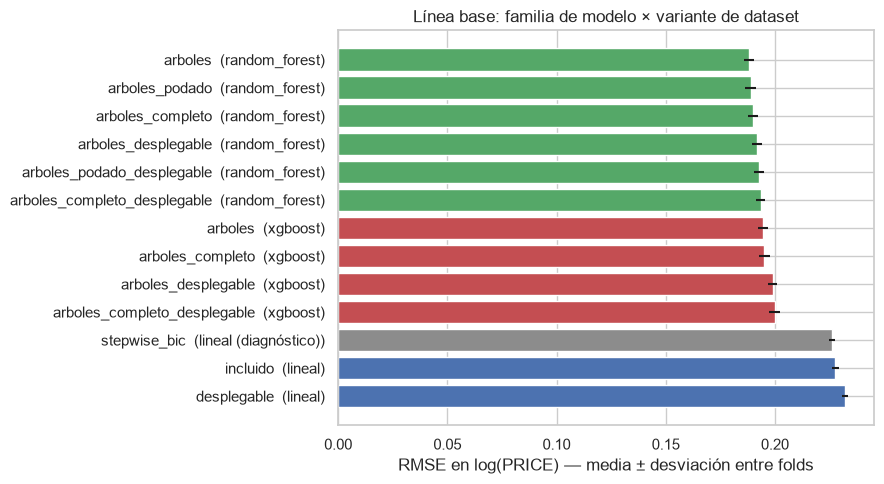

In [10]:
tabla_todos = pd.DataFrame(resultados).sort_values("rmse_log_media")
print(tabla_todos[["nombre", "familia", "rmse_log_media", "rmse_log_std", "tiempo_s"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
etiquetas = tabla_todos["nombre"] + "  (" + tabla_todos["familia"] + ")"
colores = tabla_todos["familia"].map({
    "lineal": "#4C72B0", "lineal (diagn\u00f3stico)": "#8C8C8C",
    "random_forest": "#55A868", "xgboost": "#C44E52",
})
ax.barh(etiquetas, tabla_todos["rmse_log_media"], xerr=tabla_todos["rmse_log_std"], color=colores)
ax.invert_yaxis()
ax.set_xlabel("RMSE en log(PRICE) \u2014 media \u00b1 desviaci\u00f3n entre folds")
ax.set_title("L\u00ednea base: familia de modelo \u00d7 variante de dataset")
plt.tight_layout()
plt.show()

## 6. Contrato con `06_fine_tuning.ipynb`

Regla de selección: para cada familia competidora (lineal, random_forest,
xgboost) avanza la variante con menor `rmse_log` medio, entre **todas** las
variantes evaluadas para esa familia — incluidas las `*_desplegable`.

Los modelos lineales quedan descartados por tener una `performance` significativamente inferior.

In [11]:
familias_competidoras = ["lineal", "random_forest", "xgboost"]
ganadores = (
    pd.DataFrame(resultados)
    .query("familia in @familias_competidoras")
    .sort_values("rmse_log_media")
    .groupby("familia", as_index=False)
    .first()
    [["familia", "nombre", "rmse_log_media", "rmse_log_std"]]
)
print(ganadores.to_string(index=False))

print(f"\nRegistro completo: {RUTA_RESULTADOS}")
print("stepwise_bic: reportado en \u00a72.1, no compite por continuar (ver raz\u00f3n all\u00ed).")

      familia   nombre  rmse_log_media  rmse_log_std
       lineal incluido        0.227674      0.001433
random_forest  arboles        0.188023      0.002285
      xgboost  arboles        0.194441      0.002423

Registro completo: C:\Users\tomas\Documents\Master\habitia-madrid\data\results\resultados_baseline.csv
stepwise_bic: reportado en §2.1, no compite por continuar (ver razón allí).
